# GPU V3 — Tăng tốc Non-Local Means bằng Cross-Correlation

Notebook này đánh giá **GPU V3** của thuật toán Non-Local Means (NLM).

## Mục tiêu của V3

Ba phiên bản GPU được xây dựng theo ba hướng tối ưu khác nhau:

- **GPU V1 — Parallelism:** mỗi CUDA thread xử lý một output pixel.
- **GPU V2 — Memory reuse:** dùng Shared Memory với tile + halo để giảm truy cập lặp vào Global Memory.
- **GPU V3 — Computation reformulation:** biến đổi công thức patch distance để tận dụng **patch energy + cross-correlation**.

V3 sử dụng đẳng thức:

$$
\|P-Q\|^2 = \|P\|^2 + \|Q\|^2 - 2\langle P,Q\rangle
$$

Trong đó:

- $\|P\|^2$: năng lượng của reference patch;
- $\|Q\|^2$: năng lượng của candidate patch;
- $\langle P,Q\rangle$: cross-correlation / dot product giữa hai patch.

Ý tưởng này được lấy cảm hứng từ repository tham khảo **Fast Non-Local Means and Asymptotic Non-Local Means**. Implementation trong project này **không copy nguyên code MATLAB**, mà giữ cùng semantics của GPU V1/V2 để có thể kiểm tra correctness trực tiếp.

## Cấu hình benchmark chính

- Image: `512 × 512`
- Patch: `7 × 7`
- Search window: `21 × 21`
- CUDA block: `16 × 16`
- V3 displacement batch mặc định: `32`

## 1. Chuẩn bị môi trường

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Thư mục gốc dự án:", PROJECT_ROOT)

Thư mục gốc dự án: e:\Lap trinh song song ud\gpu_dense_vector_retrieval


### Import thư viện và các implementation

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cupy as cp

from src.nlm.config import NLMConfig

from src.nlm.image_utils import (
    add_gaussian_noise,
    create_camera_test_image,
)

from src.nlm.metrics import (
    compare_outputs,
    evaluate_denoising,
)

from src.nlm.benchmark import (
    benchmark_cuda_kernel,
    benchmark_gpu_end_to_end,
)

from src.nlm.gpu_v1 import (
    nlm_gpu_v1,
    create_gpu_v1_kernel_launcher,
)

from src.nlm.gpu_v2 import (
    nlm_gpu_v2,
    prepare_gpu_v2_kernel_launch,
)

from src.nlm.gpu_v3 import (
    nlm_gpu_v3,
    prepare_gpu_v3_pipeline_launch,
    create_gpu_v3_kernel_launcher,
)

print("Import thành công.")

Import thành công.


### Kiểm tra GPU CUDA

In [3]:
device = cp.cuda.Device()
properties = cp.cuda.runtime.getDeviceProperties(device.id)

device_name = properties["name"]
if isinstance(device_name, bytes):
    device_name = device_name.decode()

print("CUDA device ID:", device.id)
print("Tên GPU:", device_name)
print(
    "Compute capability:",
    f'{properties["major"]}.{properties["minor"]}',
)

CUDA device ID: 0
Tên GPU: NVIDIA GeForce RTX 3050 Laptop GPU
Compute capability: 8.6


## 2. Cấu hình thí nghiệm

Ở V3, ta dùng workload lớn hơn cấu hình `3×3 / 7×7` ban đầu.

Với:

- patch `7×7` → 49 phần tử mỗi patch;
- search window `21×21` → 441 candidate positions;

nếu tính patch distance trực tiếp, mỗi output pixel có thể cần tới:

$
441 \times 49 = 21{,}609
$

phép so sánh phần tử patch.

Cấu hình lớn này giúp làm rõ bottleneck của patch-distance computation và tạo điều kiện để đánh giá V3.

In [4]:
config = NLMConfig(
    image_size=512,
    noise_sigma=0.08,
    patch_size=7,
    search_window_size=21,
    h=0.12,
    random_seed=42,
    block_size_x=16,
    block_size_y=16,
)

V3_BATCH_SIZE = 32

patch_radius = config.patch_radius
search_radius = config.search_radius
padding_radius = config.padding_radius

print("Kích thước ảnh:", config.image_size)
print("Patch size:", config.patch_size)
print("Search window:", config.search_window_size)
print("Patch radius:", patch_radius)
print("Search radius:", search_radius)
print("Padding / halo radius:", padding_radius)
print("CUDA block:", config.block_size)
print("V3 displacement batch size:", V3_BATCH_SIZE)

Kích thước ảnh: 512
Patch size: 7
Search window: 21
Patch radius: 3
Search radius: 10
Padding / halo radius: 13
CUDA block: (16, 16)
V3 displacement batch size: 32


### So sánh khối lượng tính toán với cấu hình nhỏ

In [5]:
small_patch_size = 3
small_search_window = 7

small_work_per_pixel = (
    small_patch_size ** 2
    * small_search_window ** 2
)

large_work_per_pixel = (
    config.patch_size ** 2
    * config.search_window_size ** 2
)

workload_ratio = (
    large_work_per_pixel
    / small_work_per_pixel
)

print(
    "Cấu hình 3x3 / 7x7:",
    small_work_per_pixel,
    "patch-element comparisons / output pixel",
)

print(
    "Cấu hình 7x7 / 21x21:",
    large_work_per_pixel,
    "patch-element comparisons / output pixel",
)

print(
    "Khối lượng tính trực tiếp tăng khoảng:",
    f"{workload_ratio:.1f}×",
)

Cấu hình 3x3 / 7x7: 441 patch-element comparisons / output pixel
Cấu hình 7x7 / 21x21: 21609 patch-element comparisons / output pixel
Khối lượng tính trực tiếp tăng khoảng: 49.0×


## 3. Tạo ảnh đầu vào dùng chung

GPU V1, V2 và V3 phải dùng **cùng một ảnh nhiễu** để việc so sánh là công bằng.

`seed` được cố định để mỗi lần chạy notebook đều tạo cùng dữ liệu đầu vào.

In [6]:
clean_image = create_camera_test_image(
    image_size=config.image_size,
)

noisy_image = add_gaussian_noise(
    image=clean_image,
    sigma=config.noise_sigma,
    seed=config.random_seed,
)

clean_image = np.ascontiguousarray(
    clean_image,
    dtype=np.float32,
)

noisy_image = np.ascontiguousarray(
    noisy_image,
    dtype=np.float32,
)

print("Ảnh sạch:")
print("  shape:", clean_image.shape)
print("  dtype:", clean_image.dtype)
print(
    "  range:",
    float(clean_image.min()),
    "→",
    float(clean_image.max()),
)

print("\nẢnh nhiễu:")
print("  shape:", noisy_image.shape)
print("  dtype:", noisy_image.dtype)
print(
    "  range:",
    float(noisy_image.min()),
    "→",
    float(noisy_image.max()),
)

Ảnh sạch:
  shape: (512, 512)
  dtype: float32
  range: 0.0 → 1.0

Ảnh nhiễu:
  shape: (512, 512)
  dtype: float32
  range: 0.0 → 1.0


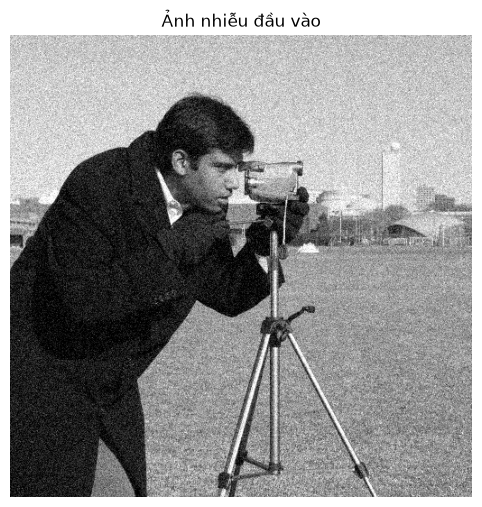

In [7]:
plt.figure(figsize=(6, 6))
plt.imshow(
    noisy_image,
    cmap="gray",
    vmin=0.0,
    vmax=1.0,
)
plt.title("Ảnh nhiễu đầu vào")
plt.axis("off")
plt.show()

## 4. Ý tưởng GPU V3 — Cross-Correlation

Ở GPU V1/V2, patch distance về bản chất vẫn được tính trực tiếp:

$$
D(P,Q)
=
\frac{1}{|P|}
\sum_{k \in P}
(P_k-Q_k)^2
$$

GPU V3 viết lại thành:

$$
D(P,Q)
=
\frac{
\|P\|^2
+
\|Q\|^2
-
2\langle P,Q\rangle
}{|P|}
$$

### Pipeline của V3

```text
Padded image
    │
    ├──> Patch-energy map: ||P||²
    │
    └──> Batch nhiều search displacements
             │
             ├──> Product maps: I(x) × I(x+d)
             │
             ├──> Horizontal box sum
             │
             ├──> Vertical accumulation
             │       → cross-correlation <P,Q>
             │
             ├──> Patch distance
             │       ||P||² + ||Q||² - 2<P,Q>
             │
             └──> NLM weight + weighted accumulation
    │
    └──> Normalize output
```

Điểm quan trọng so với V3 running-sum trước đó là **nhiều displacement được xử lý theo batch** thay vì tạo một nhóm kernel riêng cho từng displacement.

### Kiểm tra cấu trúc batch của V3

In [8]:
v3_prepared = prepare_gpu_v3_pipeline_launch(
    image=noisy_image,
    patch_size=config.patch_size,
    search_window_size=config.search_window_size,
    h=config.h,
    block_size=config.block_size,
    displacement_batch_size=V3_BATCH_SIZE,
)

number_of_displacements = (
    v3_prepared["number_of_displacements"]
)

number_of_batches = (
    v3_prepared["number_of_batches"]
)

effective_batch_size = (
    v3_prepared["displacement_batch_size"]
)

estimated_pipeline_launches = (
    1                      # patch-energy kernel
    + 3 * number_of_batches
    + 1                    # normalize kernel
)

print(
    "Số search displacements:",
    number_of_displacements,
)

print(
    "Batch size:",
    effective_batch_size,
)

print(
    "Số batch:",
    number_of_batches,
)

print(
    "Số CUDA kernel launches ước tính cho pipeline:",
    estimated_pipeline_launches,
)

Số search displacements: 441
Batch size: 32
Số batch: 14
Số CUDA kernel launches ước tính cho pipeline: 44


Với search window `21×21`, có **441 displacement**.

Nếu `batch_size = 32`, 441 displacement được chia thành khoảng **14 batch**.  
Mỗi batch dùng một nhóm kernel để xử lý nhiều displacement cùng lúc.

Đây là điểm cần benchmark: batching giảm số lần launch kernel, nhưng batch lớn hơn cũng làm tăng kích thước intermediate buffers và memory traffic.

## 5. Chạy GPU V1, GPU V2 và GPU V3

In [9]:
denoised_gpu_v1 = nlm_gpu_v1(
    image=noisy_image,
    patch_size=config.patch_size,
    search_window_size=config.search_window_size,
    h=config.h,
    block_size=config.block_size,
)

denoised_gpu_v2 = nlm_gpu_v2(
    image=noisy_image,
    patch_size=config.patch_size,
    search_window_size=config.search_window_size,
    h=config.h,
    block_size=config.block_size,
)

denoised_gpu_v3 = nlm_gpu_v3(
    image=noisy_image,
    patch_size=config.patch_size,
    search_window_size=config.search_window_size,
    h=config.h,
    block_size=config.block_size,
    displacement_batch_size=V3_BATCH_SIZE,
)

print("GPU V1:", denoised_gpu_v1.shape, denoised_gpu_v1.dtype)
print("GPU V2:", denoised_gpu_v2.shape, denoised_gpu_v2.dtype)
print("GPU V3:", denoised_gpu_v3.shape, denoised_gpu_v3.dtype)

GPU V1: (512, 512) float32
GPU V2: (512, 512) float32
GPU V3: (512, 512) float32


### So sánh trực quan

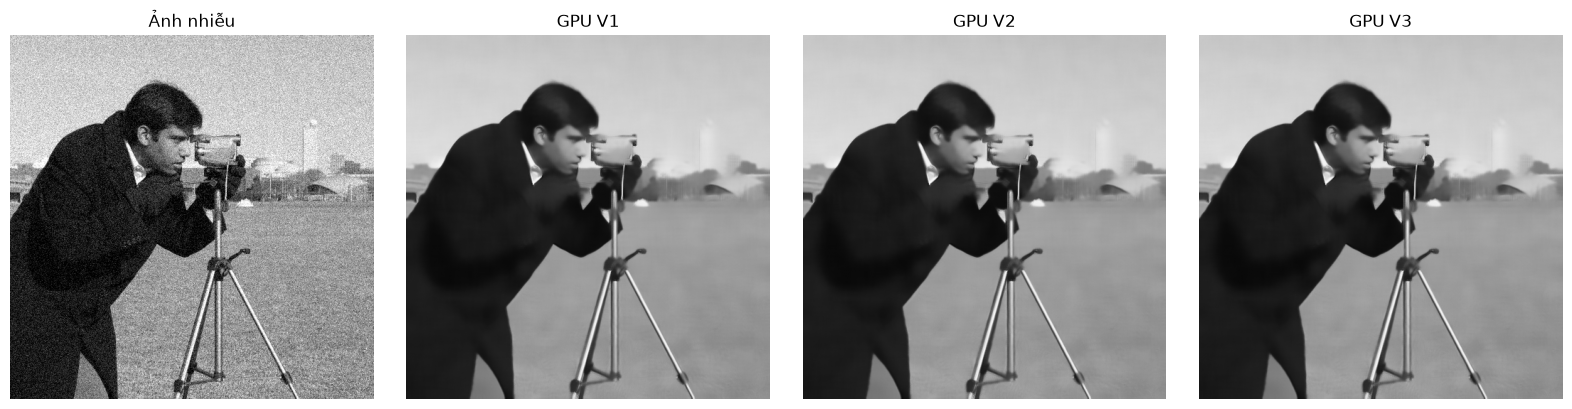

In [10]:
fig, axes = plt.subplots(
    1,
    4,
    figsize=(16, 4),
)

images = [
    noisy_image,
    denoised_gpu_v1,
    denoised_gpu_v2,
    denoised_gpu_v3,
]

titles = [
    "Ảnh nhiễu",
    "GPU V1",
    "GPU V2",
    "GPU V3",
]

for ax, image, title in zip(
    axes,
    images,
    titles,
):
    ax.imshow(
        image,
        cmap="gray",
        vmin=0.0,
        vmax=1.0,
    )
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.show()

## 6. Kiểm tra correctness

Mục tiêu của V3 là thay đổi **cách tính**, không thay đổi kết quả NLM.

Vì vậy V3 phải khớp với GPU V1/V2 trong sai số floating-point cho phép.

In [11]:
gpu_v3_vs_v1 = compare_outputs(
    reference=denoised_gpu_v1,
    candidate=denoised_gpu_v3,
    atol=5e-5,
    rtol=5e-5,
)

gpu_v3_vs_v2 = compare_outputs(
    reference=denoised_gpu_v2,
    candidate=denoised_gpu_v3,
    atol=5e-5,
    rtol=5e-5,
)

print("GPU V3 so với GPU V1:")
display(gpu_v3_vs_v1)

print("GPU V3 so với GPU V2:")
display(gpu_v3_vs_v2)

GPU V3 so với GPU V1:


{'max_absolute_error': 1.7285346984863281e-06,
 'mean_absolute_error': 1.8322596417874593e-07,
 'rmse': 2.647354186347535e-07,
 'allclose': True}

GPU V3 so với GPU V2:


{'max_absolute_error': 1.7285346984863281e-06,
 'mean_absolute_error': 1.8322596417874593e-07,
 'rmse': 2.647354186347535e-07,
 'allclose': True}

In [12]:
max_abs_error_v3_v1 = float(
    np.max(
        np.abs(
            denoised_gpu_v3
            - denoised_gpu_v1
        )
    )
)

max_abs_error_v3_v2 = float(
    np.max(
        np.abs(
            denoised_gpu_v3
            - denoised_gpu_v2
        )
    )
)

correctness_table = pd.DataFrame(
    [
        {
            "So sánh": "GPU V3 vs GPU V1",
            "Max absolute error": (
                max_abs_error_v3_v1
            ),
            "Allclose": np.allclose(
                denoised_gpu_v3,
                denoised_gpu_v1,
                atol=5e-5,
                rtol=5e-5,
            ),
        },
        {
            "So sánh": "GPU V3 vs GPU V2",
            "Max absolute error": (
                max_abs_error_v3_v2
            ),
            "Allclose": np.allclose(
                denoised_gpu_v3,
                denoised_gpu_v2,
                atol=5e-5,
                rtol=5e-5,
            ),
        },
    ]
)

correctness_table

,So sánh,Max absolute error,Allclose
0,GPU V3 vs GPU V1,0.000002,True
1,GPU V3 vs GPU V2,0.000002,True


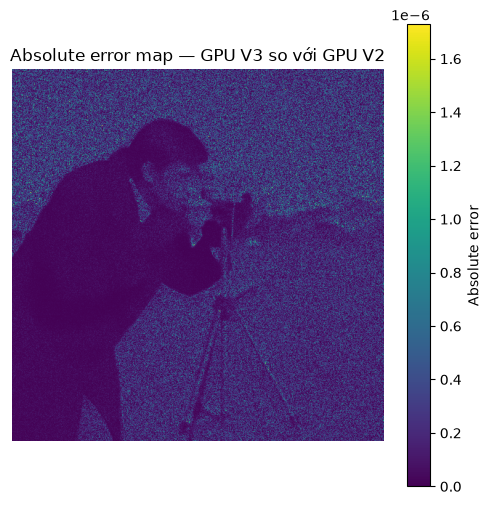

In [13]:
error_map = np.abs(
    denoised_gpu_v3
    - denoised_gpu_v2
)

plt.figure(figsize=(6, 6))
plt.imshow(error_map)
plt.title("Absolute error map — GPU V3 so với GPU V2")
plt.axis("off")
plt.colorbar(label="Absolute error")
plt.show()

## 7. Đánh giá chất lượng denoising

PSNR/SSIM được dùng để kiểm tra rằng việc reformulate patch distance không làm thay đổi đáng kể chất lượng ảnh.

Ở đây mục tiêu **không phải** chứng minh V3 cho ảnh đẹp hơn V1/V2, mà là xác nhận ba implementation đang thực hiện cùng một phép lọc NLM.

In [14]:
gpu_v1_quality = evaluate_denoising(
    clean=clean_image,
    noisy=noisy_image,
    denoised=denoised_gpu_v1,
)

gpu_v2_quality = evaluate_denoising(
    clean=clean_image,
    noisy=noisy_image,
    denoised=denoised_gpu_v2,
)

gpu_v3_quality = evaluate_denoising(
    clean=clean_image,
    noisy=noisy_image,
    denoised=denoised_gpu_v3,
)

quality_table = pd.DataFrame(
    [
        {
            "Implementation": "GPU V1",
            **gpu_v1_quality,
        },
        {
            "Implementation": "GPU V2",
            **gpu_v2_quality,
        },
        {
            "Implementation": "GPU V3",
            **gpu_v3_quality,
        },
    ]
)

quality_table

,Implementation,noisy_psnr,denoised_psnr,denoised_ssim,psnr_improvement
0,GPU V1,22.232281,27.925106,0.731726,5.692825
1,GPU V2,22.232281,27.925106,0.731726,5.692825
2,GPU V3,22.232281,27.925106,0.731726,5.692825


## 8. Benchmark GPU compute-only

### Phạm vi đo

`benchmark_cuda_kernel()` dùng CUDA Events.

- GPU V1: đo CUDA kernel của V1.
- GPU V2: đo CUDA kernel của V2.
- GPU V3: đo **toàn bộ multi-kernel compute pipeline** của V3.

Các input/buffer GPU được chuẩn bị trước nên phạm vi này không bao gồm:

- CPU padding;
- Host-to-Device transfer;
- Device-to-Host transfer;
- one-time allocation ở phía Python.

Vì V3 có nhiều kernel, notebook dùng tên **GPU compute-only**, không gọi đây là “single-kernel runtime”.

In [15]:
v1_launcher, v1_output_gpu = (
    create_gpu_v1_kernel_launcher(
        image=noisy_image,
        patch_size=config.patch_size,
        search_window_size=config.search_window_size,
        h=config.h,
        block_size=config.block_size,
    )
)

v2_prepared = prepare_gpu_v2_kernel_launch(
    image=noisy_image,
    patch_size=config.patch_size,
    search_window_size=config.search_window_size,
    h=config.h,
    block_size=config.block_size,
)

v2_launcher = v2_prepared[
    "kernel_launcher"
]

v3_prepared = prepare_gpu_v3_pipeline_launch(
    image=noisy_image,
    patch_size=config.patch_size,
    search_window_size=config.search_window_size,
    h=config.h,
    block_size=config.block_size,
    displacement_batch_size=V3_BATCH_SIZE,
)

v3_launcher = v3_prepared[
    "kernel_launcher"
]

print("Đã chuẩn bị xong V1/V2/V3 GPU launchers.")

Đã chuẩn bị xong V1/V2/V3 GPU launchers.


### Pre-warm trước khi đo

In [16]:
PREWARM_RUNS = 15

for _ in range(PREWARM_RUNS):
    v1_launcher()

for _ in range(PREWARM_RUNS):
    v2_launcher()

for _ in range(PREWARM_RUNS):
    v3_launcher()

cp.cuda.get_current_stream().synchronize()

print(
    f"Đã pre-warm mỗi implementation {PREWARM_RUNS} lần."
)

Đã pre-warm mỗi implementation 15 lần.


In [17]:
v1_compute_benchmark = benchmark_cuda_kernel(
    kernel_launcher=v1_launcher,
    warmup_runs=10,
    measured_runs=50,
)

v2_compute_benchmark = benchmark_cuda_kernel(
    kernel_launcher=v2_launcher,
    warmup_runs=10,
    measured_runs=50,
)

v3_compute_benchmark = benchmark_cuda_kernel(
    kernel_launcher=v3_launcher,
    warmup_runs=10,
    measured_runs=50,
)

print("GPU V1 compute-only:")
display(v1_compute_benchmark)

print("GPU V2 compute-only:")
display(v2_compute_benchmark)

print("GPU V3 compute-only:")
display(v3_compute_benchmark)

GPU V1 compute-only:


{'times_ms': array([25.26822472, 25.24057579, 25.23238373, 25.24057579, 25.14841652,
        25.03680038, 25.01119995, 24.92723274, 24.92723274, 24.92723274,
        24.94259262, 24.93337631, 24.93440056, 24.92723274, 24.94463921,
        24.92518425, 24.92723274, 24.9354248 , 24.92313576, 24.93132782,
        25.03680038, 25.0439682 , 25.03372765, 25.02860832, 25.04089546,
        25.10438347, 25.03577614, 25.17196846, 25.03884888, 25.05011177,
        25.06956863, 25.1525116 , 25.37369537, 25.36652756, 25.34604836,
        25.43411255, 25.49350357, 25.45971107, 25.45868874, 25.44230461,
        25.44128036, 25.44947243, 25.45049667, 25.42284775, 25.34502411,
        25.33683205, 25.33171272, 25.24774361, 25.34297562, 25.14329529]),
 'median_ms': 25.123839378356934,
 'mean_ms': 25.159557266235353,
 'std_ms': 0.19486983726164409,
 'min_ms': 24.92313575744629,
 'max_ms': 25.49350357055664}

GPU V2 compute-only:


{'times_ms': array([24.0261116 , 24.01791954, 24.19712067, 24.4152317 , 24.41420746,
        24.40499115, 24.40192032, 24.41113663, 24.46131134, 24.68044853,
        24.31078339, 24.30463982, 24.33331108, 24.39782333, 24.39884758,
        24.40089607, 24.41420746, 24.46335983, 24.39987183, 24.59545517,
        24.91699219, 24.99584007, 25.00198364, 25.02246475, 25.02144051,
        25.02758408, 25.00505638, 25.00812721, 25.0009594 , 25.01734352,
        25.02553558, 24.99891281, 24.94259262, 24.90777588, 24.90470314,
        24.90470314, 24.90777588, 24.89855957, 24.90265656, 24.90265656,
        24.93644714, 24.94156837, 24.93951988, 24.93849564, 24.90982437,
        24.89651108, 24.94259262, 24.90163231, 24.89548874, 24.90777588]),
 'median_ms': 24.90265655517578,
 'mean_ms': 24.719462280273437,
 'std_ms': 0.3014235165534457,
 'min_ms': 24.017919540405273,
 'max_ms': 25.027584075927734}

GPU V3 compute-only:


{'times_ms': array([17.9701767 , 17.91897583, 17.93126488, 17.9046402 , 17.98656082,
        17.89952087, 17.89030457, 17.90771294, 17.92000008, 17.88825607,
        17.8933754 , 17.88006401, 17.95788765, 17.88723183, 17.88415909,
        17.81043243, 17.74489594, 17.69267273, 17.70803261, 17.75923157,
        17.62713623, 17.62918472, 17.65171242, 17.65068817, 17.6558075 ,
        17.6332798 , 17.8053112 , 17.66809654, 17.67731285, 17.72543907,
        17.63942337, 17.64556885, 17.65478325, 17.73363113, 17.65888023,
        17.6988163 , 17.6558075 , 17.65068817, 17.67219162, 17.65273666,
        17.61382484, 17.67424011, 17.65478325, 17.64966393, 17.65683174,
        17.66297531, 17.69267273, 18.57740784, 17.7305603 , 17.66912079]),
 'median_ms': 17.695744514465332,
 'mean_ms': 17.768079452514648,
 'std_ms': 0.16335028293733028,
 'min_ms': 17.61382484436035,
 'max_ms': 18.577407836914062}

In [18]:
v1_compute_ms = (
    v1_compute_benchmark["median_ms"]
)

v2_compute_ms = (
    v2_compute_benchmark["median_ms"]
)

v3_compute_ms = (
    v3_compute_benchmark["median_ms"]
)

compute_table = pd.DataFrame(
    [
        {
            "Implementation": "GPU V1",
            "Tối ưu chính": (
                "Pixel-level parallelism"
            ),
            "Median compute-only (ms)": (
                v1_compute_ms
            ),
            "Speedup so với V1": 1.0,
        },
        {
            "Implementation": "GPU V2",
            "Tối ưu chính": (
                "Shared Memory reuse"
            ),
            "Median compute-only (ms)": (
                v2_compute_ms
            ),
            "Speedup so với V1": (
                v1_compute_ms
                / v2_compute_ms
            ),
        },
        {
            "Implementation": "GPU V3",
            "Tối ưu chính": (
                "Cross-correlation reformulation"
            ),
            "Median compute-only (ms)": (
                v3_compute_ms
            ),
            "Speedup so với V1": (
                v1_compute_ms
                / v3_compute_ms
            ),
        },
    ]
)

compute_table

,Implementation,Tối ưu chính,Median compute-only (ms),Speedup so với V1
0,GPU V1,Pixel-level parallelism,25.123839,1.000000
1,GPU V2,Shared Memory reuse,24.902657,1.008882
2,GPU V3,Cross-correlation reformulation,17.695745,1.419767


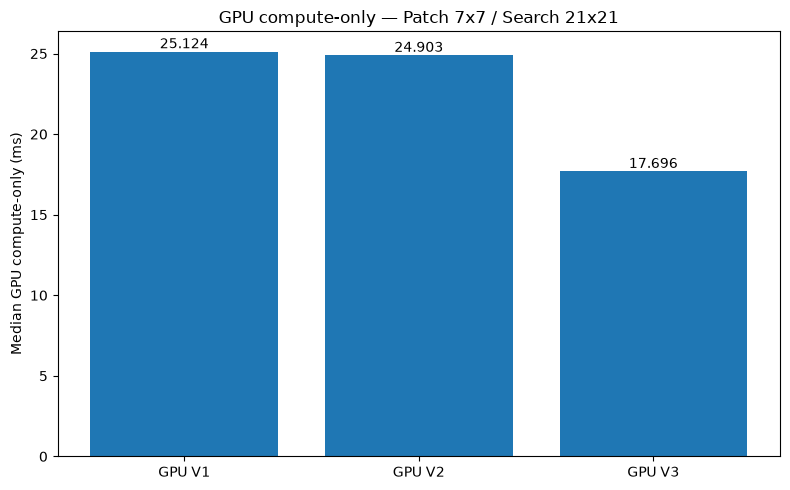

In [19]:
labels = ["GPU V1", "GPU V2", "GPU V3"]
compute_values = [
    v1_compute_ms,
    v2_compute_ms,
    v3_compute_ms,
]

plt.figure(figsize=(8, 5))
bars = plt.bar(
    labels,
    compute_values,
)

plt.ylabel("Median GPU compute-only (ms)")
plt.title(
    "GPU compute-only — Patch 7x7 / Search 21x21"
)

for bar, value in zip(
    bars,
    compute_values,
):
    plt.text(
        bar.get_x()
        + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.3f}",
        ha="center",
        va="bottom",
    )

plt.tight_layout()
plt.show()

## 9. Benchmark steady-state end-to-end

End-to-end benchmark đo toàn bộ lời gọi implementation, có thể bao gồm:

- CPU padding;
- Host-to-Device transfer;
- GPU allocation;
- CUDA computation;
- Device-to-Host transfer;
- output conversion.

Warm-up được thực hiện trước để giảm ảnh hưởng của first-time CUDA initialization và kernel compilation.

In [20]:
def run_v1_end_to_end():
    return nlm_gpu_v1(
        image=noisy_image,
        patch_size=config.patch_size,
        search_window_size=config.search_window_size,
        h=config.h,
        block_size=config.block_size,
    )


def run_v2_end_to_end():
    return nlm_gpu_v2(
        image=noisy_image,
        patch_size=config.patch_size,
        search_window_size=config.search_window_size,
        h=config.h,
        block_size=config.block_size,
    )


def run_v3_end_to_end():
    return nlm_gpu_v3(
        image=noisy_image,
        patch_size=config.patch_size,
        search_window_size=config.search_window_size,
        h=config.h,
        block_size=config.block_size,
        displacement_batch_size=V3_BATCH_SIZE,
    )

In [21]:
v1_end_to_end = benchmark_gpu_end_to_end(
    function=run_v1_end_to_end,
    warmup_runs=10,
    measured_runs=50,
)

v2_end_to_end = benchmark_gpu_end_to_end(
    function=run_v2_end_to_end,
    warmup_runs=10,
    measured_runs=50,
)

v3_end_to_end = benchmark_gpu_end_to_end(
    function=run_v3_end_to_end,
    warmup_runs=10,
    measured_runs=50,
)

print("GPU V1 end-to-end:")
display(v1_end_to_end)

print("GPU V2 end-to-end:")
display(v2_end_to_end)

print("GPU V3 end-to-end:")
display(v3_end_to_end)

GPU V1 end-to-end:


{'times_seconds': array([0.0271085, 0.0271483, 0.0269807, 0.0271924, 0.0270199, 0.0269227,
        0.0273803, 0.0283527, 0.0301643, 0.0301641, 0.0300182, 0.0300072,
        0.0299171, 0.0296426, 0.0292864, 0.0288616, 0.02869  , 0.0287867,
        0.0288309, 0.029016 , 0.0288928, 0.0286356, 0.0281585, 0.0280007,
        0.0283985, 0.0280887, 0.0282707, 0.0282116, 0.0283466, 0.0280114,
        0.0280139, 0.0287023, 0.0286137, 0.0286998, 0.0282659, 0.028136 ,
        0.0294222, 0.0291697, 0.0295224, 0.0294494, 0.0295096, 0.0290778,
        0.0293927, 0.0289864, 0.0291505, 0.0289873, 0.0292027, 0.0291233,
        0.0295227, 0.0295036]),
 'median_seconds': 0.02880880000157049,
 'mean_seconds': 0.02869915199931711,
 'std_seconds': 0.0008635595474698798,
 'min_seconds': 0.026922699995338917,
 'max_seconds': 0.030164299998432398}

GPU V2 end-to-end:


{'times_seconds': array([0.0266135, 0.0262588, 0.0265867, 0.0263746, 0.0263886, 0.0270621,
        0.0265096, 0.0263713, 0.0266304, 0.026525 , 0.0263797, 0.026712 ,
        0.0268642, 0.027651 , 0.0278258, 0.0277299, 0.0275609, 0.0277425,
        0.0276535, 0.0276498, 0.0276136, 0.0275806, 0.0277141, 0.027546 ,
        0.0276717, 0.0276086, 0.0274999, 0.0272932, 0.0269578, 0.0267999,
        0.0270006, 0.0268817, 0.026895 , 0.0269289, 0.026867 , 0.0274008,
        0.0282903, 0.0268392, 0.0272288, 0.0274771, 0.0266325, 0.0268881,
        0.0269095, 0.0267532, 0.027091 , 0.0268873, 0.0268542, 0.0269526,
        0.0271244, 0.0271019]),
 'median_seconds': 0.02695520000270335,
 'mean_seconds': 0.02708758800115902,
 'std_seconds': 0.0004749673192353108,
 'min_seconds': 0.026258799989591353,
 'max_seconds': 0.028290299989748746}

GPU V3 end-to-end:


{'times_seconds': array([0.0193524, 0.0197882, 0.0197016, 0.0197963, 0.0200666, 0.0197883,
        0.0202036, 0.0202027, 0.0246411, 0.0207545, 0.0196772, 0.0194882,
        0.0194011, 0.0193651, 0.019366 , 0.0193975, 0.0194404, 0.0193942,
        0.0194453, 0.0194392, 0.0194902, 0.0195393, 0.0193081, 0.0191877,
        0.0191238, 0.0191445, 0.0191932, 0.0190668, 0.0192237, 0.0190834,
        0.0190836, 0.0191445, 0.0189335, 0.0188312, 0.0188889, 0.0191331,
        0.0189079, 0.0188508, 0.0188798, 0.0190308, 0.0191958, 0.0189013,
        0.0189456, 0.0190257, 0.0190681, 0.0193311, 0.0191733, 0.0191579,
        0.0192071, 0.0192683]),
 'median_seconds': 0.019245999996201135,
 'mean_seconds': 0.019440569998696446,
 'std_seconds': 0.0008368255511870871,
 'min_seconds': 0.01883119999547489,
 'max_seconds': 0.024641099997097626}

In [22]:
v1_e2e_ms = (
    v1_end_to_end["median_seconds"]
    * 1000.0
)

v2_e2e_ms = (
    v2_end_to_end["median_seconds"]
    * 1000.0
)

v3_e2e_ms = (
    v3_end_to_end["median_seconds"]
    * 1000.0
)

end_to_end_table = pd.DataFrame(
    [
        {
            "Implementation": "GPU V1",
            "Median end-to-end (ms)": (
                v1_e2e_ms
            ),
            "Speedup so với V1": 1.0,
        },
        {
            "Implementation": "GPU V2",
            "Median end-to-end (ms)": (
                v2_e2e_ms
            ),
            "Speedup so với V1": (
                v1_e2e_ms / v2_e2e_ms
            ),
        },
        {
            "Implementation": "GPU V3",
            "Median end-to-end (ms)": (
                v3_e2e_ms
            ),
            "Speedup so với V1": (
                v1_e2e_ms / v3_e2e_ms
            ),
        },
    ]
)

end_to_end_table

,Implementation,Median end-to-end (ms),Speedup so với V1
0,GPU V1,28.8088,1.000000
1,GPU V2,26.9552,1.068766
2,GPU V3,19.2460,1.496872


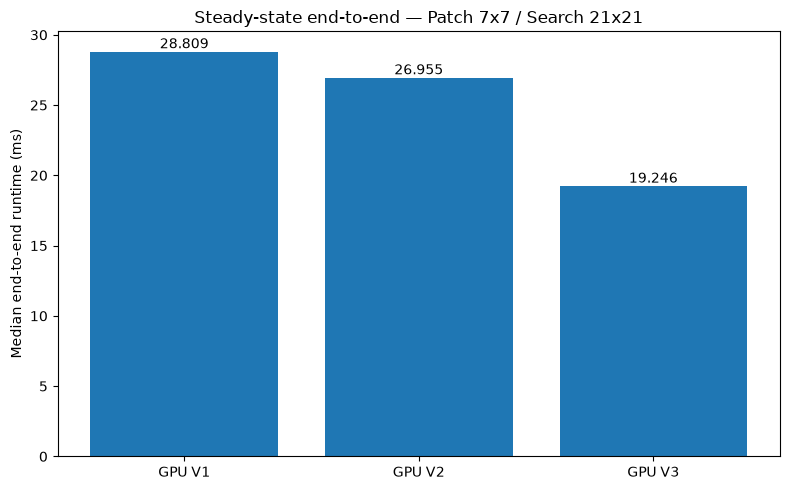

In [23]:
labels = ["GPU V1", "GPU V2", "GPU V3"]
e2e_values = [
    v1_e2e_ms,
    v2_e2e_ms,
    v3_e2e_ms,
]

plt.figure(figsize=(8, 5))
bars = plt.bar(
    labels,
    e2e_values,
)

plt.ylabel("Median end-to-end runtime (ms)")
plt.title(
    "Steady-state end-to-end — Patch 7x7 / Search 21x21"
)

for bar, value in zip(
    bars,
    e2e_values,
):
    plt.text(
        bar.get_x()
        + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.3f}",
        ha="center",
        va="bottom",
    )

plt.tight_layout()
plt.show()

## 10. Thí nghiệm batch size của GPU V3

`displacement_batch_size` là tham số thiết kế quan trọng của V3.

- Batch nhỏ → nhiều batch hơn → nhiều kernel launches hơn.
- Batch lớn → ít kernel launches hơn nhưng intermediate buffers lớn hơn và memory traffic có thể tăng.

Ta thử:

```text
8, 16, 32, 64
```

và đo **GPU compute-only** cho từng cấu hình.

In [24]:
BATCH_SIZES = [8, 16, 32, 64]

batch_results = []

for batch_size in BATCH_SIZES:
    prepared = prepare_gpu_v3_pipeline_launch(
        image=noisy_image,
        patch_size=config.patch_size,
        search_window_size=config.search_window_size,
        h=config.h,
        block_size=config.block_size,
        displacement_batch_size=batch_size,
    )

    launcher = prepared[
        "kernel_launcher"
    ]

    # Pre-warm riêng cho cấu hình batch hiện tại.
    for _ in range(5):
        launcher()

    cp.cuda.get_current_stream().synchronize()

    result = benchmark_cuda_kernel(
        kernel_launcher=launcher,
        warmup_runs=5,
        measured_runs=20,
    )

    batch_results.append(
        {
            "Batch size": batch_size,
            "Số displacement": (
                prepared[
                    "number_of_displacements"
                ]
            ),
            "Số batch": (
                prepared["number_of_batches"]
            ),
            "Median compute-only (ms)": (
                result["median_ms"]
            ),
            "Mean (ms)": (
                result["mean_ms"]
            ),
            "Std (ms)": (
                result["std_ms"]
            ),
        }
    )

batch_table = pd.DataFrame(
    batch_results
)

batch_table

,Batch size,Số displacement,Số batch,Median compute-only (ms),Mean (ms),Std (ms)
0,8,441,56,20.242432,20.201523,0.861144
1,16,441,28,18.249216,18.265958,0.044883
2,32,441,14,18.026497,18.084352,0.155061
3,64,441,7,18.105856,18.040627,0.156674


In [25]:
best_batch_row = batch_table.loc[
    batch_table[
        "Median compute-only (ms)"
    ].idxmin()
]

best_batch_size = int(
    best_batch_row["Batch size"]
)

best_batch_runtime_ms = float(
    best_batch_row[
        "Median compute-only (ms)"
    ]
)

print(
    "Batch size tốt nhất trong sweep:",
    best_batch_size,
)

print(
    "Median compute-only tương ứng:",
    f"{best_batch_runtime_ms:.3f} ms",
)

Batch size tốt nhất trong sweep: 32
Median compute-only tương ứng: 18.026 ms


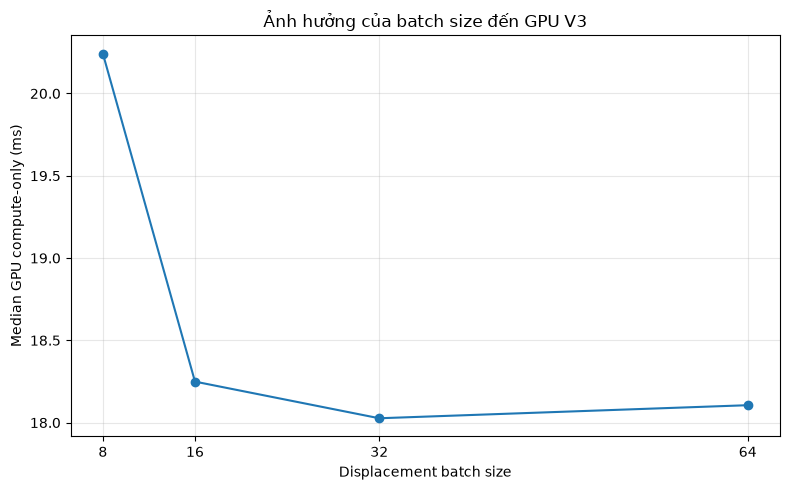

In [26]:
plt.figure(figsize=(8, 5))

plt.plot(
    batch_table["Batch size"],
    batch_table[
        "Median compute-only (ms)"
    ],
    marker="o",
)

plt.xlabel("Displacement batch size")
plt.ylabel("Median GPU compute-only (ms)")
plt.title("Ảnh hưởng của batch size đến GPU V3")
plt.xticks(BATCH_SIZES)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Benchmark lại V3 với batch size tốt nhất

Cell này giúp phân biệt:

- **V3 mặc định (`batch=32`)**
- **V3 sau khi tuning batch size**

Việc tuning chỉ thay đổi cách chia batch, không thay đổi thuật toán hay output.

In [27]:
def run_v3_tuned_end_to_end():
    return nlm_gpu_v3(
        image=noisy_image,
        patch_size=config.patch_size,
        search_window_size=config.search_window_size,
        h=config.h,
        block_size=config.block_size,
        displacement_batch_size=best_batch_size,
    )


v3_tuned_end_to_end = benchmark_gpu_end_to_end(
    function=run_v3_tuned_end_to_end,
    warmup_runs=10,
    measured_runs=50,
)

v3_tuned_e2e_ms = (
    v3_tuned_end_to_end["median_seconds"]
    * 1000.0
)

print(
    "GPU V3 tuned end-to-end:",
    f"{v3_tuned_e2e_ms:.3f} ms",
)

GPU V3 tuned end-to-end: 19.715 ms


In [28]:
best_v3_prepared = prepare_gpu_v3_pipeline_launch(
    image=noisy_image,
    patch_size=config.patch_size,
    search_window_size=config.search_window_size,
    h=config.h,
    block_size=config.block_size,
    displacement_batch_size=best_batch_size,
)

best_v3_launcher = (
    best_v3_prepared["kernel_launcher"]
)

for _ in range(10):
    best_v3_launcher()

cp.cuda.get_current_stream().synchronize()

best_v3_compute_benchmark = benchmark_cuda_kernel(
    kernel_launcher=best_v3_launcher,
    warmup_runs=10,
    measured_runs=50,
)

best_v3_compute_ms = (
    best_v3_compute_benchmark[
        "median_ms"
    ]
)

print(
    "V3 batch mặc định:",
    V3_BATCH_SIZE,
    "→",
    f"{v3_compute_ms:.3f} ms",
)

print(
    "V3 batch tốt nhất:",
    best_batch_size,
    "→",
    f"{best_v3_compute_ms:.3f} ms",
)

print(
    "Speedup V3 tuned so với V1:",
    f"{v1_compute_ms / best_v3_compute_ms:.2f}×",
)

print(
    "Speedup V3 tuned so với V2:",
    f"{v2_compute_ms / best_v3_compute_ms:.2f}×",
)

V3 batch mặc định: 32 → 17.696 ms
V3 batch tốt nhất: 32 → 18.516 ms
Speedup V3 tuned so với V1: 1.36×
Speedup V3 tuned so với V2: 1.34×


## 11. Tổng hợp kết quả

In [ ]:
summary_table = pd.DataFrame(
    [
        {
            "Phiên bản": "GPU V1",
            "Ý tưởng chính": (
                "Song song hóa theo output pixel"
            ),
            "Compute-only (ms)": (
                v1_compute_ms
            ),
            "End-to-end (ms)": (
                v1_e2e_ms
            ),
        },
        {
            "Phiên bản": "GPU V2",
            "Ý tưởng chính": (
                "Shared Memory tile + halo"
            ),
            "Compute-only (ms)": (
                v2_compute_ms
            ),
            "End-to-end (ms)": (
                v2_e2e_ms
            ),
        },
        {
            "Phiên bản": (
                f"GPU V3 (batch={V3_BATCH_SIZE})"
            ),
            "Ý tưởng chính": (
                "Cross-correlation + batching"
            ),
            "Compute-only (ms)": (
                v3_compute_ms
            ),
            "End-to-end (ms)": (
                v3_e2e_ms
            ),
        },
    ]
)

summary_table

,Phiên bản,Ý tưởng chính,Compute-only (ms),End-to-end (ms)
0,GPU V1,Song song hóa theo output pixel,25.123839,28.80880
1,GPU V2,Shared Memory tile + halo,24.902657,26.95520
2,GPU V3 (batch=32),Cross-correlation + batching,17.695745,19.24600
3,GPU V3 tuned (batch=32),Cross-correlation + tuned batching,18.515968,19.71475



Có thể kết luận rằng reformulation bằng patch energy + cross-correlation, kết hợp batching, đã giảm chi phí repeated patch-distance computation đủ để bù cho intermediate memory traffic và multi-kernel overhead.
